In [2]:
EXPERIMENT = "Elongation-3D-TwoCellTypes"

SAVE_FIGURES = False

# Imports

In [36]:
import jax
import jax.numpy as np
import equinox as eqx

jax.config.update("jax_enable_x64", True)

import jax_morph as jxm  # type: ignore

key = jax.random.PRNGKey(0)

import matplotlib.pyplot as plt

from tqdm import trange

In [37]:
from fig2_istate_and_model import build_istate, build_model

if SAVE_FIGURES:
    # create the figures subdirectory if it doesn't exist
    import os
    os.makedirs("figures", exist_ok=True)

# Utils

In [38]:
def load_run_data_fig2(run_id, key):
    """Load training log, initial state, and trained model for a given run.

    Args:
        run_id: String identifier for the training run
        key: JAX random key

    Returns:
        training_log: ReinforceTrainingLog object
        istate: Initial CellState
        initial_model: Initial model
        trained_model: Trained model
    """
    import pickle

    # Load training log
    training_log = pickle.load(open(f"{run_id}/training_log_{run_id}.pkl", "rb"))

    # Load initial state
    istate = build_istate()

    # Load model
    model = build_model(key, istate)

    # Load initial model
    fh = open(f"{run_id}/init_model_{run_id}.eqx", "rb")
    initial_model = eqx.tree_deserialise_leaves(fh, like=model)

    # Load trained model
    fh = open(f"{run_id}/trained_model_{run_id}.eqx", "rb")
    trained_model = eqx.tree_deserialise_leaves(fh, like=model)

    return training_log, istate, initial_model, trained_model

# Load Single Run Data

In [6]:
RUN_ID = "run_1738109412"

In [7]:
# Load data
key, init_model_key = jax.random.split(key)
training_log, istate, initial_model, trained_model = load_run_data_fig2(
    RUN_ID, init_model_key
)

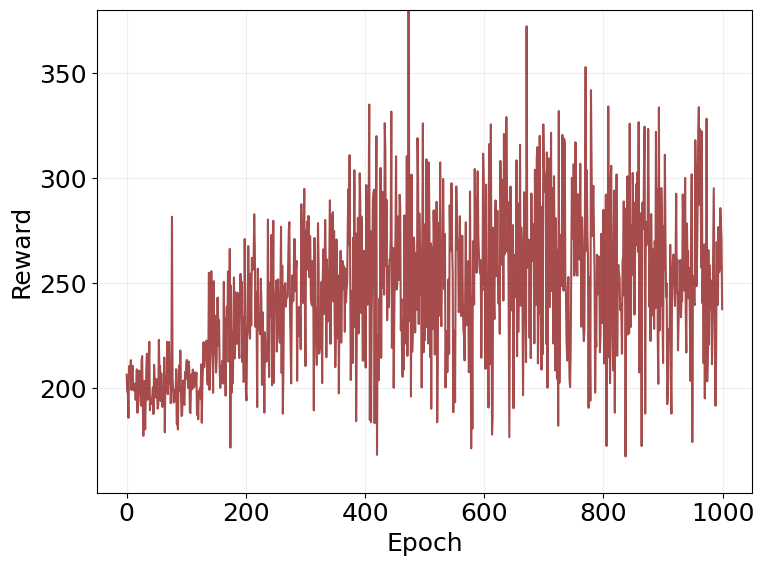

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(training_log.rewards, color="maroon", alpha=0.7)
plt.ylim(plt.gca().get_ylim()[0], 380)
plt.xlabel("Epoch")
plt.ylabel("Reward")
plt.grid(alpha=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/reward_curve_{RUN_ID}.svg", dpi=300)

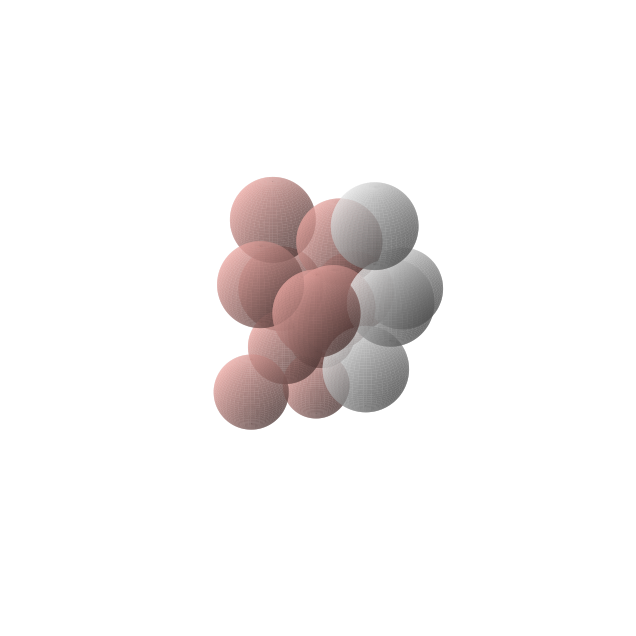

In [9]:
fig, ax = jxm.visualization.draw_spheres(
    istate,
    color_field="celltype",
    elev=30,
    azim=0,
    cm=plt.get_cmap("Pastel1"),
    colorbar=False,
    alpha=0.6,
)

if SAVE_FIGURES:
    plt.savefig(f"figures/istate_celltype_{RUN_ID}.png", dpi=300)

In [39]:
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

key, subkey = jax.random.split(key)
fstate_untr, _ = jxm.simulate(initial_model, istate, key=subkey, n_steps=N_ADD)

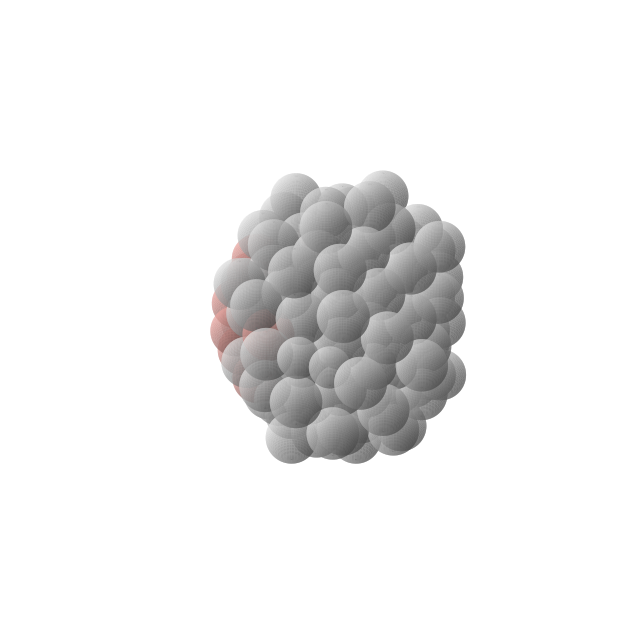

In [11]:
fig, ax = jxm.visualization.draw_spheres(
    fstate_untr,
    color_field="celltype",
    elev=30,
    azim=0,
    cm=plt.get_cmap("Pastel1"),
    colorbar=False,
    alpha=0.6,
)

if SAVE_FIGURES:
    plt.savefig(f"figures/untrained_sim_celltype_{RUN_ID}.png", dpi=300)

# Final State Analysis

In [40]:
N_SIMS = 9
N_ADD = int(istate.celltype.shape[0] - istate.celltype.sum(-1).sum(-1))

# Unoptimized Simulations
fstates_init = []
for i in trange(N_SIMS):
    key, subkey = jax.random.split(key)
    fstate, _ = jxm.simulate(initial_model, istate, key=subkey, n_steps=N_ADD)
    fstates_init += [fstate]

# Optimized Simulations
fstates_opt = []
for i in trange(N_SIMS):
    key, subkey = jax.random.split(key)
    fstate, _ = jxm.simulate(trained_model, istate, key=subkey, n_steps=N_ADD)
    fstates_opt += [fstate]

100%|██████████| 9/9 [00:24<00:00,  2.70s/it]


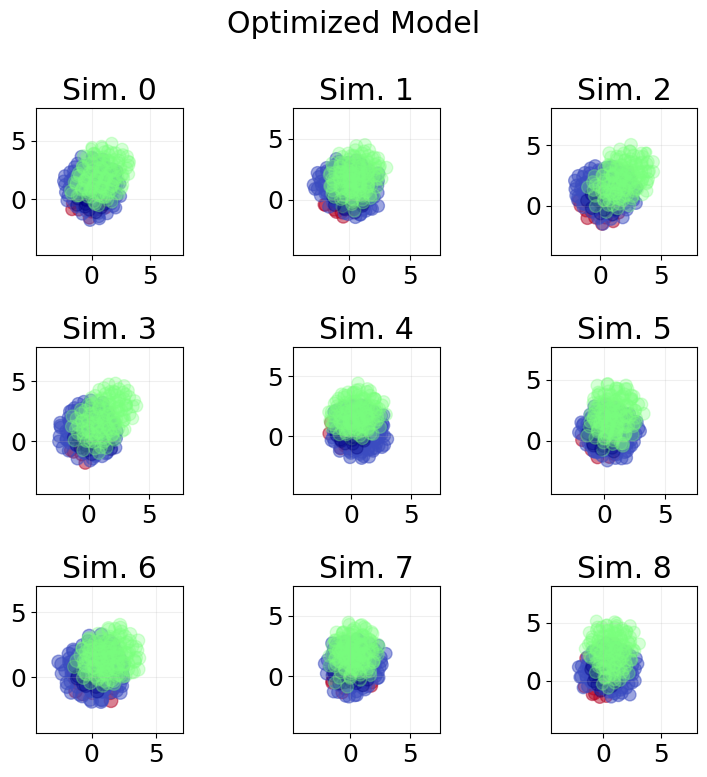

In [41]:
# Calculate number of rows and columns needed for subplots
n_cols = int(np.ceil(np.sqrt(N_SIMS)))
n_rows = int(np.ceil(N_SIMS / n_cols))

# Create a grid of subplots for all simulations
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axs = axs.ravel()

# Plot each simulation pair
for i in range(N_SIMS):
    # Plot initial simulation
    fig, ax = jxm.visualization.draw_circles_ctype(
        fstates_init[i], grid=True, ax=axs[i]
    )

    # Overlay optimized simulation with transparency
    fig, ax = jxm.visualization.draw_circles_ctypes(
        fstates_opt[i], grid=True, ax=axs[i], alpha=0.3, cm=plt.get_cmap("jet_r")
    )

    axs[i].set_title(f"Sim. {i}")

# Hide any empty subplots
for i in range(N_SIMS, len(axs)):
    axs[i].set_visible(False)

plt.suptitle("Optimized Model")

plt.tight_layout()

In [42]:
# Pruning

# remove edges based on order of magnitude
pruning_mask = np.log(np.abs(trained_model.GeneNetwork.interaction_matrix)) > -1.0
pruned_network = np.where(pruning_mask, trained_model.GeneNetwork.interaction_matrix, 0)

# manually remove self-interaction
pruned_network = pruned_network.at[0, 0].set(0.0)

pruned_model_basic = eqx.tree_at(
    lambda model: model.GeneNetwork.interaction_matrix, trained_model, pruned_network
)

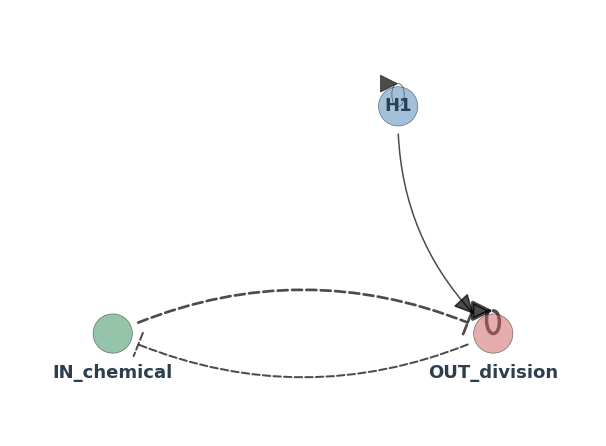

In [43]:
fig, ax = jxm.visualization.draw_gene_network(
    pruned_model_basic.GeneNetwork,
    style={"node_size": 800, "font_size": 13, "edge_width_scale": 2.5},
)
ax.margins(x=0.2, y=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_network_basic_{RUN_ID}.png", dpi=300)

In [44]:
trained_model.GeneNetwork.expression_offset

Array([[-1.57166587, -0.23873248,  0.73284747]], dtype=float64)

**NOTE:** The hidden gene H1 is always active, so we can remove it from the network and add its approximate contribution to the offeset of the output gene.

In [45]:
ext_pruned_net = pruned_model_basic.GeneNetwork.interaction_matrix.at[1, :].set(0.0)
pruned_model = eqx.tree_at(
    lambda model: model.GeneNetwork.interaction_matrix,
    pruned_model_basic,
    ext_pruned_net,
)

ext_pruned_offset = pruned_model_basic.GeneNetwork.expression_offset.at[:, 2].set(
    pruned_model_basic.GeneNetwork.expression_offset[:, 2]
    + trained_model.GeneNetwork.interaction_matrix[1, 2] * 10
)

pruned_model = eqx.tree_at(
    lambda model: model.GeneNetwork.expression_offset, pruned_model, ext_pruned_offset
)

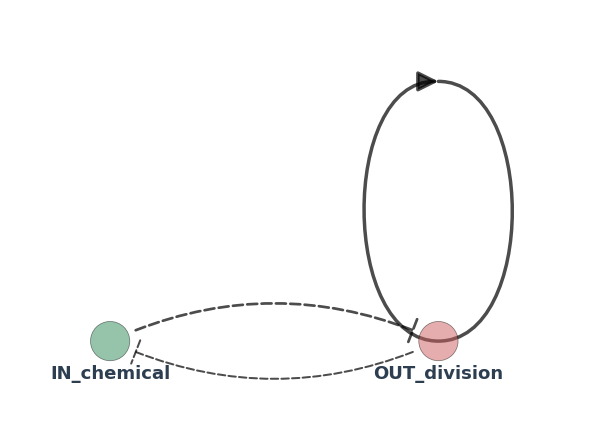

In [46]:
fig, ax = jxm.visualization.draw_gene_network(
    pruned_model.GeneNetwork,
    style={"node_size": 800, "font_size": 13, "edge_width_scale": 2.5},
)
ax.margins(x=0.2, y=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_network_{RUN_ID}.png", dpi=300)

In [47]:
# Pruned Simulations
fstates_pruned = []
for i in trange(N_SIMS):
    key, subkey = jax.random.split(key)
    fstate, _ = jxm.simulate(pruned_model, istate, key=subkey, n_steps=N_ADD)
    fstates_pruned += [fstate]

  0%|          | 0/9 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:23<00:00,  2.60s/it]


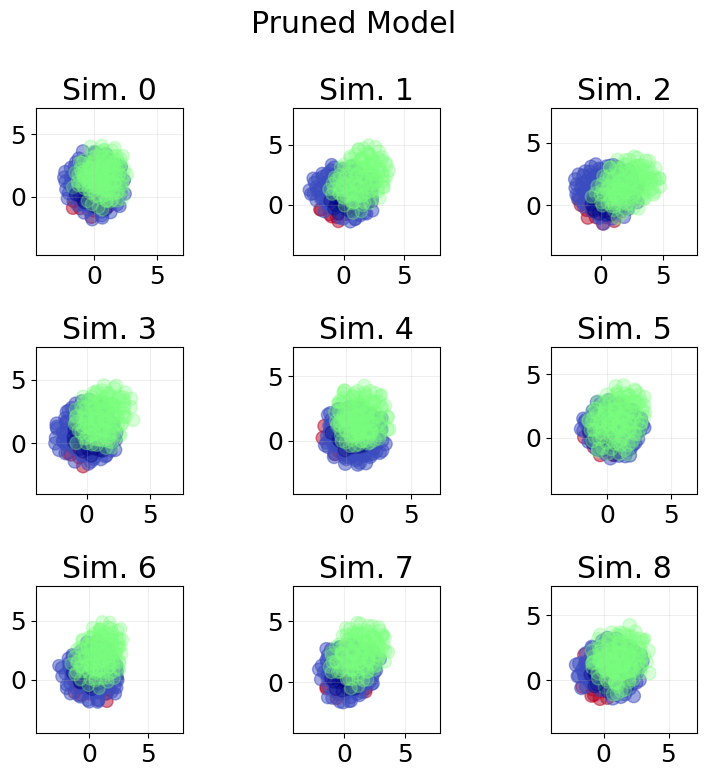

In [48]:
# Calculate number of rows and columns needed for subplots
n_cols = int(np.ceil(np.sqrt(N_SIMS)))
n_rows = int(np.ceil(N_SIMS / n_cols))

# Create a grid of subplots for all simulations
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axs = axs.ravel()

# Plot each simulation pair
for i in range(N_SIMS):
    # Plot initial simulation
    fig, ax = jxm.visualization.draw_circles_ctype(
        fstates_init[i], grid=True, ax=axs[i]
    )

    # Overlay pruned simulation with transparency
    fig, ax = jxm.visualization.draw_circles_ctypes(
        fstates_pruned[i], grid=True, ax=axs[i], alpha=0.3, cm=plt.get_cmap("jet_r")
    )

    axs[i].set_title(f"Sim. {i}")

# Hide any empty subplots
for i in range(N_SIMS, len(axs)):
    axs[i].set_visible(False)

plt.suptitle("Pruned Model")

plt.tight_layout()

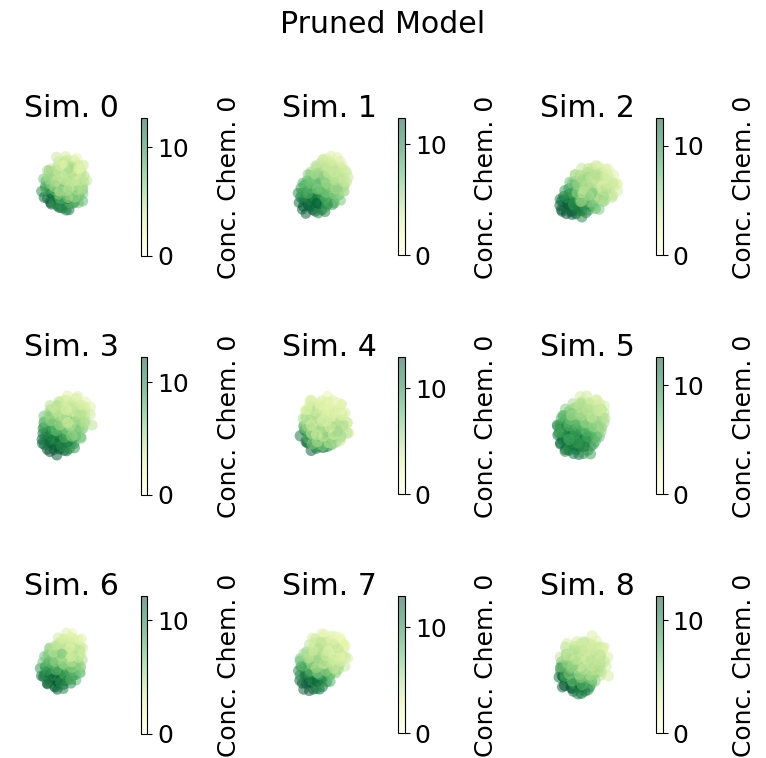

In [49]:
# Calculate number of rows and columns needed for subplots
n_cols = int(np.ceil(np.sqrt(N_SIMS)))
n_rows = int(np.ceil(N_SIMS / n_cols))

# Create a grid of subplots for all simulations
fig, axs = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 6 * n_rows))
axs = axs.ravel()

# Plot each simulation pair
for i in range(N_SIMS):

    # Overlay pruned simulation with transparency
    fig, ax = jxm.visualization.draw_circles_chem(fstates_pruned[i], ax=axs[i])
    axs[i].set_title(f"Sim. {i}")

# Hide any empty subplots
for i in range(N_SIMS, len(axs)):
    axs[i].set_visible(False)

plt.suptitle("Pruned Model")

plt.tight_layout()

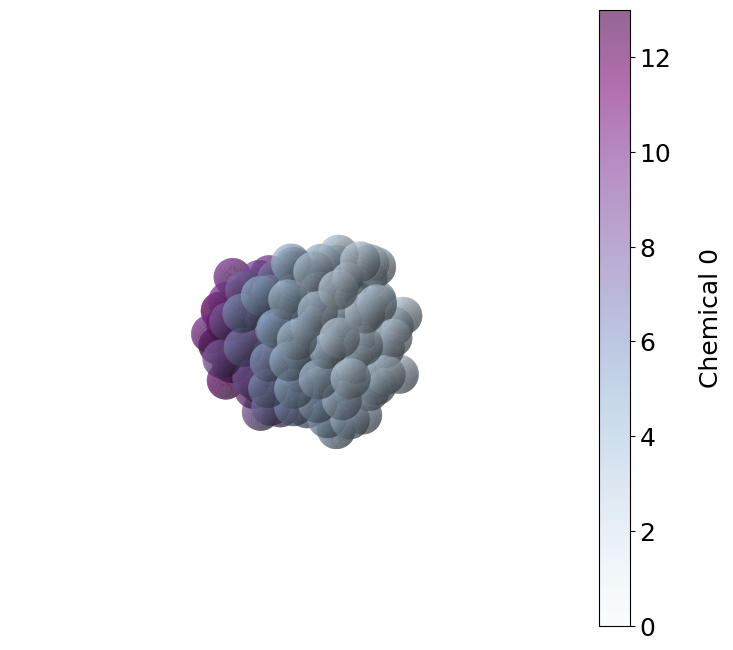

In [27]:
# NOTE: This specific final state configuration is slighlty different from the one shown in the paper
# due to randomness in the trajectory.
# The phenomena shown are the same, with minor differences due to noise.
idx_sim = 1

fig, ax = jxm.visualization.draw_spheres(fstates_pruned[idx_sim], elev=30, azim=0)

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_sim_chemical_{RUN_ID}.png", dpi=300)

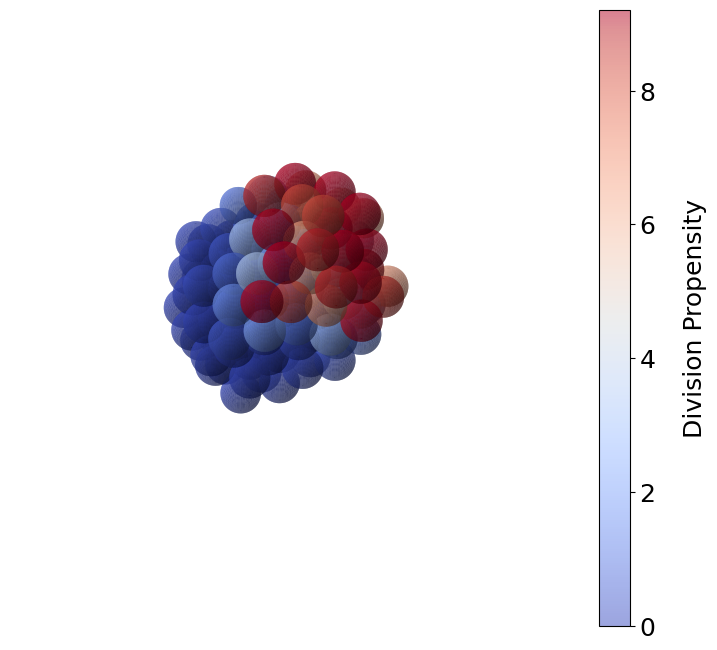

In [23]:
fig, ax = jxm.visualization.draw_spheres_division(
    fstates_pruned[idx_sim], elev=30, azim=0
)

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_sim_division_{RUN_ID}.png", dpi=300)

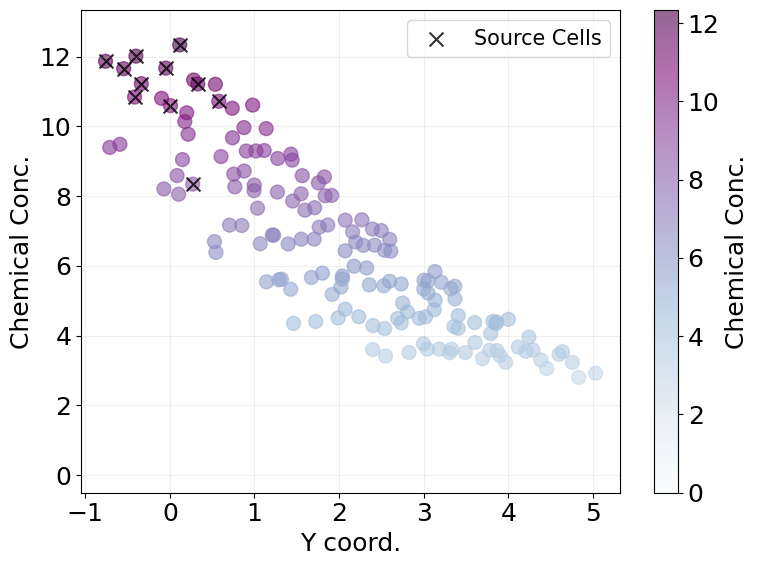

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(
    fstates_pruned[idx_sim].position[:, 1],
    fstates_pruned[idx_sim].chemical,
    alpha=0.6,
    s=100,
    c=fstates_pruned[idx_sim].chemical,
    cmap="BuPu",
    vmin=0,
)

plt.colorbar(label="Chemical Conc.")


# Add black crosses for source cells (celltype 0 or 1)
source_mask = np.bool_(fstates_pruned[idx_sim].celltype[:, 0] == 0)

plt.scatter(
    fstates_pruned[idx_sim].position[source_mask, 1],
    fstates_pruned[idx_sim].chemical[source_mask],
    marker="x",
    c="black",
    s=100,
    label="Source Cells",
    alpha=0.8,
)


plt.ylim(-0.5, fstates_pruned[idx_sim].chemical.max() + 1.0)

plt.xlabel("Y coord.")
plt.ylabel("Chemical Conc.")
plt.grid(True, alpha=0.2)

plt.legend(fontsize=15)

plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_sim_chem_profile_{RUN_ID}.svg", dpi=300)

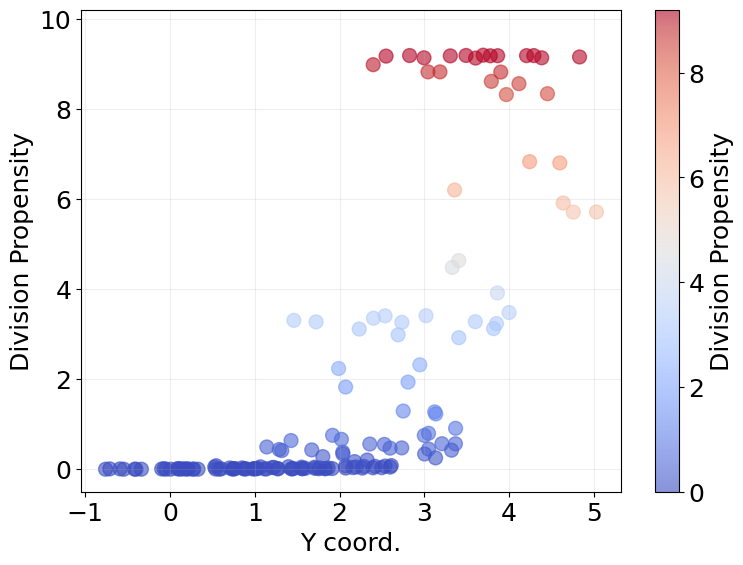

In [51]:
plt.figure(figsize=(8, 6))

plt.scatter(
    fstates_pruned[idx_sim].position[:, 1],
    fstates_pruned[idx_sim].division,
    alpha=0.6,
    s=100,
    c=fstates_pruned[idx_sim].division,
    cmap="coolwarm",
    vmin=0,
)

plt.ylim(-0.5, fstates_pruned[idx_sim].division.max() + 1.0)

plt.colorbar(label="Division Propensity")
plt.xlabel("Y coord.")
plt.ylabel("Division Propensity")
plt.grid(True, alpha=0.2)
plt.tight_layout()

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_sim_division_profile_{RUN_ID}.svg", dpi=300)

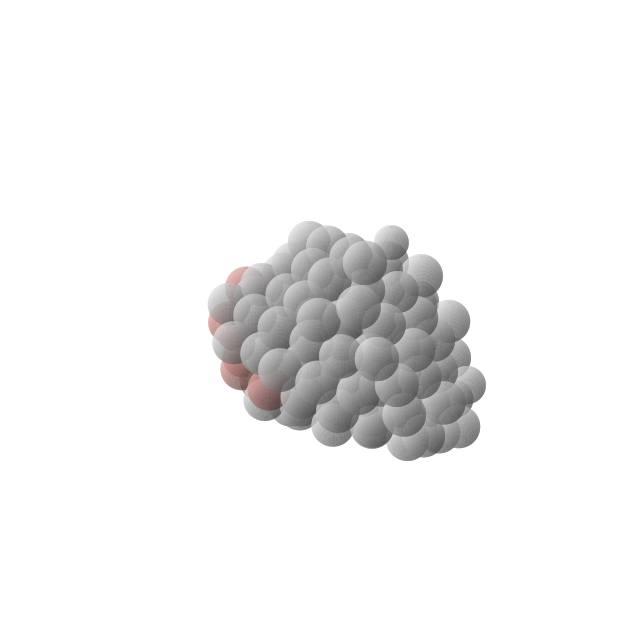

In [52]:
fig, ax = jxm.visualization.draw_spheres(
    fstates_pruned[idx_sim],
    color_field="celltype",
    elev=30,
    azim=0,
    cm=plt.get_cmap("Pastel1"),
    colorbar=False,
    alpha=0.6,
)

if SAVE_FIGURES:
    plt.savefig(f"figures/pruned_sim_celltype_{RUN_ID}.png", dpi=300)